For some reason, the ClarioSTAR software gave these files in a totally different format. I think the save settings were altered. This little script simply generates a combined CSV file with the data in the "old" format.

In [26]:
import numpy as np
from matplotlib import pyplot as plt

In [21]:
def read_new_csv(filename):
    
    s_cars = ['A;', 'B;', 'C;', 'D;', 'E;', 'F;', 'G;', 'H;']
    
    with open(filename, 'r') as f:
        
        data = []
        timepoint = []
        
        i = 0
        for line in f:
            i += 1
            
            if line.startswith('Cycle') and (len(timepoint) > 0):
                data.append(timepoint)
                timepoint = []
                
            elif line[:2] in s_cars:
                
                row = line.strip().split(';')[1:]
                assert len(row) == 12
                
                for i in range(len(row)):
                    if row[i] == '':
                        row[i] = 0
                    else:
                        row[0] = int(row[i])
                    
                timepoint.append( row )
            
    # data come in reverse time order
    # why... no one knows
    
    data = np.array(data, dtype=int)[::-1,:,:]
    assert data.shape[1:] == (8,12)
    
    return data

In [22]:
files = [
    '21-08-18 15-39-12 Mpro_FRET_TJ_Aug2021.CSV',
    '21-08-18 16-38-13 Mpro_FRET_TJ_Aug2021.CSV',
    '21-08-18 15-52-35 Mpro_FRET_TJ_Aug2021.CSV',
    '21-08-18 16-50-43 Mpro_FRET_TJ_Aug2021.CSV',
    '21-08-18 16-14-10 Mpro_FRET_TJ_Aug2021.CSV',
    '21-08-18 17-02-55 Mpro_FRET_TJ_Aug2021.CSV',
    '21-08-18 16-26-10 Mpro_FRET_TJ_Aug2021.CSV',
    '21-08-18 17-15-40 Mpro_FRET_TJ_Aug2021.CSV',
]

In [24]:
all_data = np.array([read_new_csv(f)[:98,:,:] for f in files])
print(all_data.shape)
all_data = all_data.max(axis=0)

print(all_data.shape)

(8, 98, 8, 12)
(98, 8, 12)


In [25]:

all_data

array([[[ 53695,  43117,  40389, ...,      0,      0,      0],
        [130472, 105984,  74296, ...,      0,      0,      0],
        [149844, 149844, 129483, ...,      0,      0,      0],
        ...,
        [ 16127,  16127,  10840, ...,      0,      0,      0],
        [  4119,   2909,   2792, ...,      0,      0,      0],
        [  1181,    211,    450, ...,      0,      0,      0]],

       [[ 58158,  46409,  41293, ...,      0,      0,      0],
        [140996, 110940,  78081, ...,      0,      0,      0],
        [153660, 153660, 129836, ...,      0,      0,      0],
        ...,
        [ 16479,  16479,  11288, ...,      0,      0,      0],
        [  4470,   3475,   2025, ...,      0,      0,      0],
        [  2525,     58,    136, ...,      0,      0,      0]],

       [[ 62148,  50433,  45112, ...,      0,      0,      0],
        [149377, 111855,  81468, ...,      0,      0,      0],
        [156454, 156454, 132921, ...,      0,      0,      0],
        ...,
        [ 16

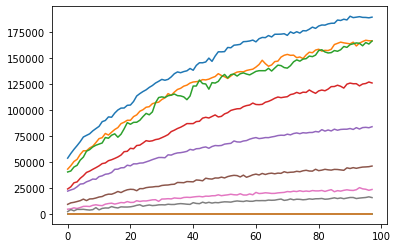

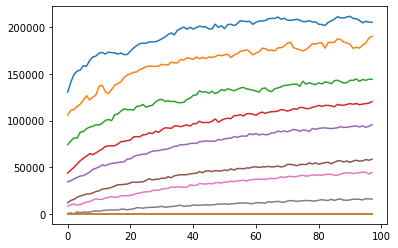

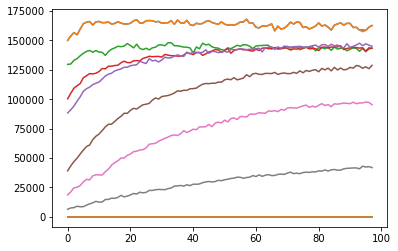

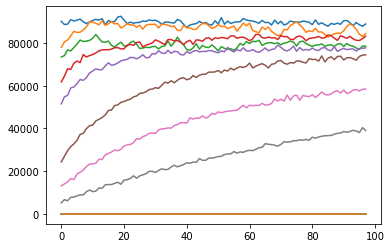

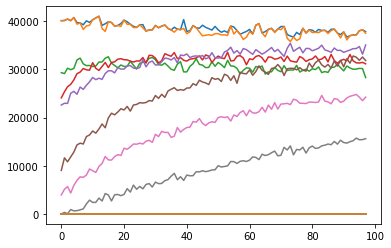

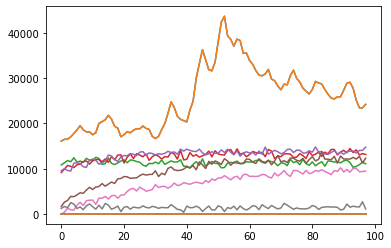

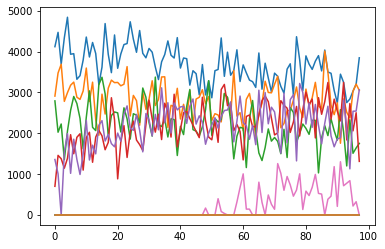

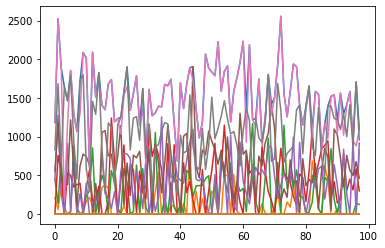

In [28]:
for i in range(8):
    plt.figure()
    plt.plot(all_data[:,i,:])
    plt.show()

In [32]:
np.savetxt('combined.csv', all_data.reshape(-1, 12), 
           delimiter=',', fmt='%8d')